In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import cv2
from tqdm import tqdm

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng device: {device}")
print(f"PyTorch version: {torch.__version__}")

Đang sử dụng device: cpu
PyTorch version: 2.8.0+cpu


In [2]:
%pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

You should consider upgrading via the 'c:\Users\vuong\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.Collecting kagglehub
     ---------------------------------------- 68.3/68.3 KB 1.2 MB/s eta 0:00:00



c:\Users\vuong\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 658M/658M [00:50<00:00, 13.6MB/s] 

Extracting files...


Path to dataset files: C:\Users\vuong\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1


In [7]:
# Định nghĩa tham số
IMG_SIZE = 128  # Kích thước ảnh
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
data_dir = os.path.join(path, "PlantVillage")  # Thư mục gốc chứa dữ liệu

print("="*50)
print("KIỂM TRA ĐƯỜNG DẪN DỮ LIỆU")
print("="*50)

# Kiểm tra đường dẫn
if not os.path.exists(data_dir):
    print(f"LỖI: Không tìm thấy thư mục {data_dir}")
    print("Vui lòng kiểm tra lại đường dẫn!")
    print(f"Thư mục hiện tại: {os.getcwd()}")
    print("Các thư mục có sẵn:")
    for item in os.listdir('.'):
        if os.path.isdir(item):
            print(f"  - {item}")
else:
    print(f"Tìm thấy thư mục: {data_dir}")
    
    # Liệt kê các lớp
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    classes.sort()
    print(f"\nTìm thấy {len(classes)} lớp:")
    for i, class_name in enumerate(classes, 1):
        # Đếm số ảnh trong mỗi lớp
        class_path = os.path.join(data_dir, class_name)
        num_images = len([f for f in os.listdir(class_path) 
                         if f.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG'))])
        print(f"{i}. {class_name}: {num_images} ảnh")
    
    NUM_CLASSES = len(classes)
    print(f"\nTổng số lớp: {NUM_CLASSES}")
    
    # Lưu class names để dùng sau
    class_names = classes

KIỂM TRA ĐƯỜNG DẪN DỮ LIỆU
Tìm thấy thư mục: C:\Users\vuong\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage

Tìm thấy 16 lớp:
1. Pepper__bell___Bacterial_spot: 997 ảnh
2. Pepper__bell___healthy: 1478 ảnh
3. PlantVillage: 0 ảnh
4. Potato___Early_blight: 1000 ảnh
5. Potato___Late_blight: 1000 ảnh
6. Potato___healthy: 152 ảnh
7. Tomato_Bacterial_spot: 2127 ảnh
8. Tomato_Early_blight: 1000 ảnh
9. Tomato_Late_blight: 1909 ảnh
10. Tomato_Leaf_Mold: 952 ảnh
11. Tomato_Septoria_leaf_spot: 1771 ảnh
12. Tomato_Spider_mites_Two_spotted_spider_mite: 1676 ảnh
13. Tomato__Target_Spot: 1404 ảnh
14. Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 ảnh
15. Tomato__Tomato_mosaic_virus: 373 ảnh
16. Tomato_healthy: 1591 ảnh

Tổng số lớp: 16


PHÂN TÍCH DỮ LIỆU CHI TIẾT
Số lớp hợp lệ: 15

Phân phối dữ liệu:
  Pepper__bell___Bacterial_spot: 997 ảnh
  Pepper__bell___healthy: 1478 ảnh
  Potato___Early_blight: 1000 ảnh
  Potato___Late_blight: 1000 ảnh
  Potato___healthy: 152 ảnh
  Tomato_Bacterial_spot: 2127 ảnh
  Tomato_Early_blight: 1000 ảnh
  Tomato_Late_blight: 1909 ảnh
  Tomato_Leaf_Mold: 952 ảnh
  Tomato_Septoria_leaf_spot: 1771 ảnh
  Tomato_Spider_mites_Two_spotted_spider_mite: 1676 ảnh
  Tomato__Target_Spot: 1404 ảnh
  Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 ảnh
  Tomato__Tomato_mosaic_virus: 373 ảnh
  Tomato_healthy: 1591 ảnh


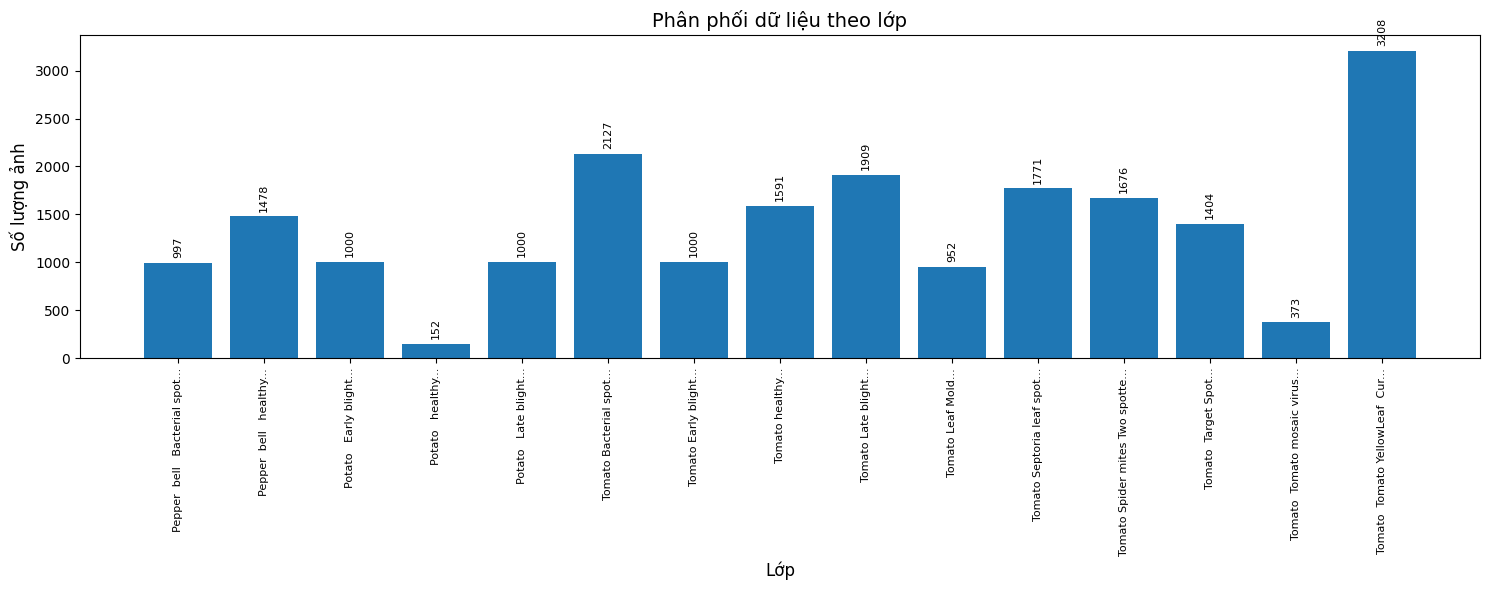


THỐNG KÊ:
  Tổng số ảnh: 20638
  Lớp nhiều nhất: Tomato__Tomato_YellowLeaf__Curl_Virus - 3208 ảnh
  Lớp ít nhất: Potato___healthy - 152 ảnh
  Tỉ lệ mất cân bằng: 21.11


In [8]:
# Lọc bỏ thư mục gốc khỏi danh sách lớp
valid_classes = []
class_counts = {}

for d in os.listdir(data_dir):
    class_path = os.path.join(data_dir, d)
    if os.path.isdir(class_path) and d != 'PlantVillage':  # Bỏ qua thư mục gốc
        num_images = len([f for f in os.listdir(class_path) 
                         if f.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG'))])
        if num_images > 0:  # Chỉ lấy lớp có ảnh
            valid_classes.append(d)
            class_counts[d] = num_images

# Sắp xếp theo tên
valid_classes.sort()
print("="*50)
print("PHÂN TÍCH DỮ LIỆU CHI TIẾT")
print("="*50)
print(f"Số lớp hợp lệ: {len(valid_classes)}")
print("\nPhân phối dữ liệu:")

for class_name in valid_classes:
    print(f"  {class_name}: {class_counts[class_name]} ảnh")

# Vẽ biểu đồ phân phối
plt.figure(figsize=(15, 6))
bars = plt.bar(range(len(class_counts)), list(class_counts.values()))
plt.xticks(range(len(class_counts)), [name.replace('_', ' ')[:30] + '...' for name in class_counts.keys()], 
           rotation=90, fontsize=8)
plt.title('Phân phối dữ liệu theo lớp', fontsize=14)
plt.ylabel('Số lượng ảnh', fontsize=12)
plt.xlabel('Lớp', fontsize=12)

# Thêm giá trị lên đầu cột
for i, (_, count) in enumerate(class_counts.items()):
    plt.text(i, count + 50, str(count), ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Thống kê
total_images = sum(class_counts.values())
min_count = min(class_counts.values())
max_count = max(class_counts.values())
min_class = min(class_counts, key=class_counts.get)
max_class = max(class_counts, key=class_counts.get)

print(f"\nTHỐNG KÊ:")
print(f"  Tổng số ảnh: {total_images}")
print(f"  Lớp nhiều nhất: {max_class} - {max_count} ảnh")
print(f"  Lớp ít nhất: {min_class} - {min_count} ảnh")
print(f"  Tỉ lệ mất cân bằng: {max_count/min_count:.2f}")

NUM_CLASSES = len(valid_classes)
class_names = valid_classes

In [10]:
from torch.utils.data import WeightedRandomSampler
import math

# Định nghĩa transforms cho training và validation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Tạo dataset
full_dataset = datasets.ImageFolder(root=data_dir)

# Lọc bỏ lớp 'PlantVillage'
valid_classes = [c for c in full_dataset.classes if c != 'PlantVillage']
print("="*50)
print("XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU")
print("="*50)
print(f"Số lớp hợp lệ: {len(valid_classes)}")

# Tạo mapping mới cho class indices
new_class_to_idx = {cls: i for i, cls in enumerate(valid_classes)}

# Lọc samples
valid_samples = []
for path, old_label in full_dataset.samples:
    old_class = full_dataset.classes[old_label]
    if old_class in valid_classes:
        new_label = new_class_to_idx[old_class]
        valid_samples.append((path, new_label))

# Tạo dataset mới
class PlantVillageDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Tạo dataset với transform tạm thời
temp_dataset = PlantVillageDataset(valid_samples, transform=train_transform)

# Tính class counts
class_counts = [0] * len(valid_classes)
for _, label in valid_samples:
    class_counts[label] += 1

print("\nSố lượng mẫu mỗi lớp:")
for i, cls in enumerate(valid_classes):
    print(f"  {i:2d}. {cls}: {class_counts[i]} ảnh")

# Tính sample weights để cân bằng
sample_weights = []
for _, label in valid_samples:
    class_weight = 1.0 / class_counts[label]
    sample_weights.append(class_weight)

# Tạo indices cho train/val split
total_samples = len(valid_samples)
indices = list(range(total_samples))
np.random.shuffle(indices)

train_size = int(0.8 * total_samples)
train_indices = indices[:train_size]
val_indices = indices[train_size:]

print(f"\nKích thước train set: {len(train_indices)} ảnh")
print(f"Kích thước val set: {len(val_indices)} ảnh")

# Tạo sampler cho training với weighted sampling
train_samples_weight = [sample_weights[i] for i in train_indices]
train_sampler = WeightedRandomSampler(
    weights=train_samples_weight,
    num_samples=len(train_indices),
    replacement=True
)

# Tạo datasets riêng cho train và val
class TrainDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

class ValDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Tạo datasets
train_samples_list = [valid_samples[i] for i in train_indices]
val_samples_list = [valid_samples[i] for i in val_indices]

train_dataset = TrainDataset(train_samples_list, transform=train_transform)
val_dataset = ValDataset(val_samples_list, transform=val_transform)

# Tạo DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    sampler=train_sampler,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=0
)

print(f"Số batch mỗi epoch (train): {len(train_loader)}")
print(f"Số batch mỗi epoch (val): {len(val_loader)}")

NUM_CLASSES = len(valid_classes)
class_names = valid_classes

XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU
Số lớp hợp lệ: 15

Số lượng mẫu mỗi lớp:
   0. Pepper__bell___Bacterial_spot: 997 ảnh
   1. Pepper__bell___healthy: 1478 ảnh
   2. Potato___Early_blight: 1000 ảnh
   3. Potato___Late_blight: 1000 ảnh
   4. Potato___healthy: 152 ảnh
   5. Tomato_Bacterial_spot: 2127 ảnh
   6. Tomato_Early_blight: 1000 ảnh
   7. Tomato_Late_blight: 1909 ảnh
   8. Tomato_Leaf_Mold: 952 ảnh
   9. Tomato_Septoria_leaf_spot: 1771 ảnh
  10. Tomato_Spider_mites_Two_spotted_spider_mite: 1676 ảnh
  11. Tomato__Target_Spot: 1404 ảnh
  12. Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 ảnh
  13. Tomato__Tomato_mosaic_virus: 373 ảnh
  14. Tomato_healthy: 1591 ảnh

Kích thước train set: 16510 ảnh
Kích thước val set: 4128 ảnh
Số batch mỗi epoch (train): 516
Số batch mỗi epoch (val): 129


In [11]:
import torch.nn.functional as F

class PlantCNN(nn.Module):
    def __init__(self, num_classes=15):
        super(PlantCNN, self).__init__()
        
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout2d(0.25)
        
        # Block 2
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout2d(0.25)
        
        # Block 3
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.dropout3 = nn.Dropout2d(0.25)
        
        # Block 4
        self.conv7 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn7 = nn.BatchNorm2d(256)
        self.conv8 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn8 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.dropout4 = nn.Dropout2d(0.25)
        
        # Tính kích thước sau các lớp conv
        self._to_linear = None
        self._get_conv_output()
        
        # Fully connected layers
        self.fc1 = nn.Linear(self._to_linear, 512)
        self.bn9 = nn.BatchNorm1d(512)
        self.dropout5 = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(512, 256)
        self.bn10 = nn.BatchNorm1d(256)
        self.dropout6 = nn.Dropout(0.5)
        
        self.fc3 = nn.Linear(256, num_classes)
        
    def _get_conv_output(self):
        # Tính kích thước output sau các lớp conv
        x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
        x = self.pool1(F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x)))))))
        x = self.dropout1(x)
        x = self.pool2(F.relu(self.bn4(self.conv4(F.relu(self.bn3(self.conv3(x)))))))
        x = self.dropout2(x)
        x = self.pool3(F.relu(self.bn6(self.conv6(F.relu(self.bn5(self.conv5(x)))))))
        x = self.dropout3(x)
        x = self.pool4(F.relu(self.bn8(self.conv8(F.relu(self.bn7(self.conv7(x)))))))
        x = self.dropout4(x)
        self._to_linear = x.numel() // x.shape[0]
        
    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Block 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)
        x = self.dropout3(x)
        
        # Block 4
        x = F.relu(self.bn7(self.conv7(x)))
        x = F.relu(self.bn8(self.conv8(x)))
        x = self.pool4(x)
        x = self.dropout4(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # FC layers
        x = F.relu(self.bn9(self.fc1(x)))
        x = self.dropout5(x)
        
        x = F.relu(self.bn10(self.fc2(x)))
        x = self.dropout6(x)
        
        x = self.fc3(x)
        
        return x

# Khởi tạo model
model = PlantCNN(num_classes=NUM_CLASSES).to(device)

print("="*50)
print("CẤU TRÚC MÔ HÌNH CNN")
print("="*50)
print(model)

# Đếm số tham số
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTổng số tham số: {total_params:,}")
print(f"Số tham số trainable: {trainable_params:,}")

CẤU TRÚC MÔ HÌNH CNN
PlantCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout2d(p=0.25, inplace=False)
  (conv5): Conv2d(64, 128, kernel_size=(

In [12]:
import time
from tqdm import tqdm

# Định nghĩa loss function và optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Lưu model tốt nhất
best_val_acc = 0.0
best_model_path = 'best_plant_model.pth'

# Lưu history
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# Early stopping parameters
target_acc = 90.0  # Mục tiêu 90%
patience = 5  # Số epoch chờ để xác nhận không cải thiện
no_improve = 0

print("="*50)
print("BẮT ĐẦU HUẤN LUYỆN")
print("="*50)
print(f"Device: {device}")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Target accuracy: >{target_acc}%")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print("="*50)

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        # Update progress bar
        train_bar.set_postfix({
            'loss': f'{train_loss/(len(train_bar)):.4f}',
            'acc': f'{100*train_correct/train_total:.2f}%'
        })
    
    train_acc = 100 * train_correct / train_total
    train_loss = train_loss / len(train_loader)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]')
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
            val_bar.set_postfix({
                'loss': f'{val_loss/(len(val_bar)):.4f}',
                'acc': f'{100*val_correct/val_total:.2f}%'
            })
    
    val_acc = 100 * val_correct / val_total
    val_loss = val_loss / len(val_loader)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, best_model_path)
        print(f"\nModel saved! Best val acc: {val_acc:.2f}%")
        no_improve = 0
    else:
        no_improve += 1
    
    # In epoch summary
    elapsed_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"\nEpoch {epoch+1}/{EPOCHS} - {elapsed_time:.2f}s")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print(f"LR: {current_lr:.6f}")
    print("-"*50)
    
    # Kiem tra nếu đạt mục tiêu
    if val_acc >= target_acc:
        print(f"\nĐÃ ĐẠT MỤC TIÊU {target_acc}%! Dừng huấn luyện.")
        print(f"Val accuracy: {val_acc:.2f}% tại epoch {epoch+1}")
        break
    
    # Early stopping condition
    if no_improve >= patience:
        print(f"\nKhông cải thiện sau {patience} epochs, dừng huấn luyện!")
        break
    
    if current_lr < 1e-7:
        print("Learning rate quá nhỏ, dừng huấn luyện!")
        break

print("\n" + "="*50)
print("KẾT THÚC HUẤN LUYỆN")
print("="*50)
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Best model saved to: {best_model_path}")

BẮT ĐẦU HUẤN LUYỆN
Device: cpu
Epochs: 50
Batch size: 32
Learning rate: 0.001
Target accuracy: >90.0%
Train samples: 16510
Val samples: 4128


Epoch 1/50 [Val]: 100%|██████████| 129/129 [01:54<00:00,  1.13it/s, loss=1.3387, acc=53.25%]



✓ Model saved! Best val acc: 53.25%

Epoch 1/50 - 1244.08s
Train Loss: 2.1147, Train Acc: 29.80%
Val Loss: 1.3387, Val Acc: 53.25%
LR: 0.001000
--------------------------------------------------


Epoch 2/50 [Val]: 100%|██████████| 129/129 [02:19<00:00,  1.08s/it, loss=0.8884, acc=68.56%]



✓ Model saved! Best val acc: 68.56%

Epoch 2/50 - 1637.76s
Train Loss: 1.5536, Train Acc: 47.26%
Val Loss: 0.8884, Val Acc: 68.56%
LR: 0.001000
--------------------------------------------------


...


✓ Model saved! Best val acc: 88.78%

Epoch 12/50 - 1307.67s
Train Loss: 0.6751, Train Acc: 77.30%
Val Loss: 0.3314, Val Acc: 88.78%
LR: 0.001000
--------------------------------------------------


Epoch 13/50 [Val]: 100%|██████████| 129/129 [01:29<00:00,  1.44it/s, loss=0.3309, acc=89.61%]



✓ Model saved! Best val acc: 89.61%

Epoch 13/50 - 1084.22s
Train Loss: 0.6529, Train Acc: 78.01%
Val Loss: 0.3309, Val Acc: 89.61%
LR: 0.001000
--------------------------------------------------


Epoch 14/50 [Val]: 100%|██████████| 129/129 [01:28<00:00,  1.45it/s, loss=0.2842, acc=90.99%]



✓ Model saved! Best val acc: 90.99%

Epoch 14/50 - 1089.72s
Train Loss: 0.6185, Train Acc: 79.32%
Val Loss: 0.2842, Val Acc: 90.99%
LR: 0.001000
--------------------------------------------------

🎉 ĐÃ ĐẠT MỤC TIÊU 90.0%! Dừng huấn luyện.
Val accuracy: 90.99% tại epoch 14

KẾT THÚC HUẤN LUYỆN
Best validation accuracy: 90.99%
Best model saved to: best_plant_model.pth


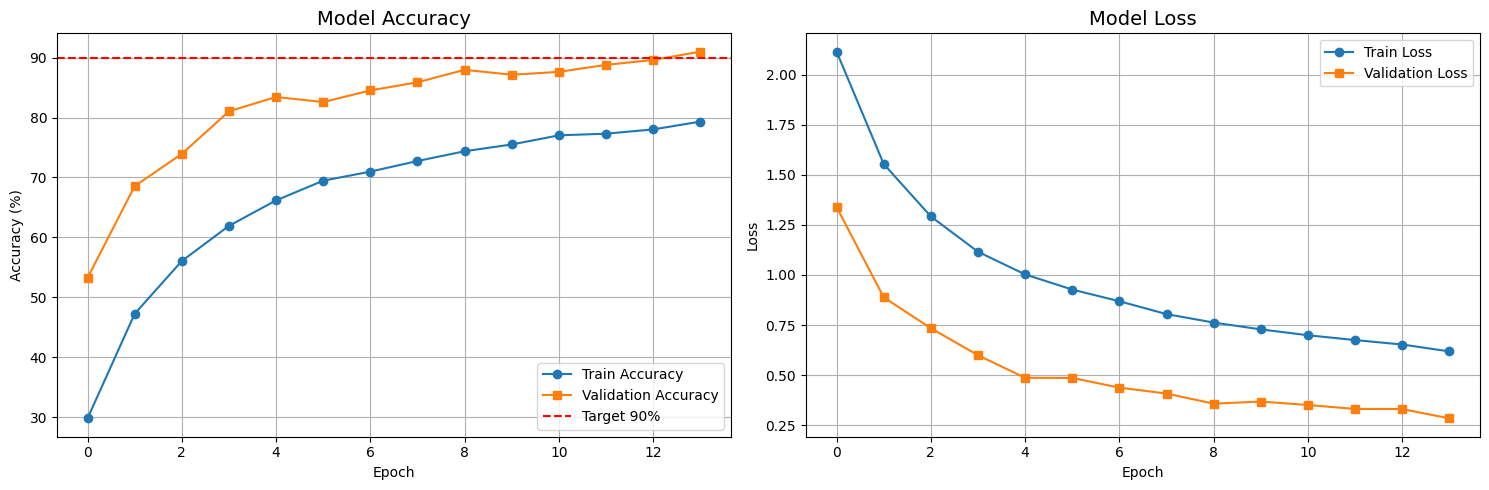

Best validation accuracy: 90.99% tại epoch 14


In [13]:
# Vẽ biểu đồ accuracy và loss
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[0].plot(history['val_acc'], label='Validation Accuracy', marker='s')
axes[0].axhline(y=90, color='r', linestyle='--', label='Target 90%')
axes[0].set_title('Model Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history['train_loss'], label='Train Loss', marker='o')
axes[1].plot(history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_title('Model Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best validation accuracy: {max(history['val_acc']):.2f}% tại epoch {history['val_acc'].index(max(history['val_acc']))+1}")